# Descriptive Clustering — What Does a Fraud-Prone Transaction Profile Look Like?

**Business question:** rather than looking at one column at a time (Phase 1's EDA), can we group transactions into natural behavioral segments — using *all* the signal we kept (numeric and categorical together) — and see whether some segments carry meaningfully more fraud risk than others?

This is a **descriptive** exercise, not a predictive one: the goal is to characterize naturally occurring transaction profiles and see how fraud distributes across them, not to build a classifier. That comes in Phase 3.

**Method: K-Prototypes.** Our data is a mix of numeric (transaction amount, anonymized `C` counts) and categorical (product code, card network/type, device type, match flags, email domain) columns. Standard K-Means only handles numeric data via Euclidean distance. K-Prototypes extends it for mixed data:
- Numeric columns → same squared-distance calculation as K-Means
- Categorical columns → simple matching dissimilarity (0 if categories match, 1 if they don't)
- The two parts are combined into one dissimilarity score per pair of points, weighted by a factor **gamma** (left at its data-driven default here, rather than hand-tuned, to keep this reproducible)
- Cluster centers ("prototypes") are recomputed each iteration using the **mean** for numeric columns and the **mode** (most frequent category) for categorical columns

**Sampling:** clustering the full ~590K rows with this method is computationally expensive (each iteration compares every point to every cluster center). We use a **40,000-row stratified sample** — sampled to preserve the overall ~3.5% fraud rate — which is fast enough to iterate on while still being large enough for a descriptive read on segment structure.

In [1]:
# One-time setup if running fresh: pip install kmodes scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_parquet('../data/gold_card_transactions.parquet')
print(f"Full dataset: {df.shape[0]:,} rows")

Full dataset: 590,540 rows


## 1. Stratified Sample

We sample 40,000 rows, stratified on `is_fraud`, so the fraud rate in our working sample matches the full dataset — this keeps our descriptive read representative rather than accidentally over- or under-weighting fraud.

In [2]:
N_SAMPLE = 40_000
sample, _ = train_test_split(df, train_size=N_SAMPLE, stratify=df['is_fraud'], random_state=42)
sample = sample.reset_index(drop=True)

print(f"Sample size: {len(sample):,}")
print(f"Fraud rate — sample: {sample['is_fraud'].mean():.3%}  |  full dataset: {df['is_fraud'].mean():.3%}")

Sample size: 40,000
Fraud rate — sample: 3.500%  |  full dataset: 3.499%


## 2. Feature Selection

We cluster on the columns that carry real behavioral signal, deliberately excluding a set of near-empty identity/device sub-fields that are 45-90% missing and largely redundant with `device_type` (they go missing for the same underlying reason: no identity data was captured for that transaction). Including a dozen overlapping, mostly-empty categorical columns would add noise to the distance calculation rather than real differentiation.

**Numeric features** (scaled before clustering, since `transaction_amount` and the `C` counts live on very different scales):
- `transaction_amount`
- `c1`–`c6` (anonymized behavioral counts — commonly associated in this dataset with things like how many addresses or devices are linked to a card)

**Categorical features** (used as-is; missing values become their own `"unknown"` category rather than being imputed — consistent with Phase 2's finding that "missing" is itself informative, not just a data gap):
- `product_code`, `card_network`, `card_type`, `billing_country_code`, `payer_email_domain`, `device_type`
- `match_flag_1`–`match_flag_9` (identity/address match indicators — known from the Kaggle competition community to carry real predictive signal)

In [3]:
numeric_cols = ['transaction_amount', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6']
categorical_cols = [
    'product_code', 'card_network', 'card_type', 'billing_country_code',
    'payer_email_domain', 'device_type',
    'match_flag_1', 'match_flag_2', 'match_flag_3', 'match_flag_4', 'match_flag_5',
    'match_flag_6', 'match_flag_7', 'match_flag_8', 'match_flag_9'
]

X = sample[numeric_cols + categorical_cols].copy()
for c in categorical_cols:
    X[c] = X[c].astype('object').fillna('unknown').astype(str)
X[numeric_cols] = X[numeric_cols].astype(float)

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X[numeric_cols])
X_final = np.hstack([X_num_scaled, X[categorical_cols].values])
categorical_idx = list(range(len(numeric_cols), len(numeric_cols) + len(categorical_cols)))

print(f"Feature matrix: {X_final.shape[0]:,} rows x {X_final.shape[1]} features "
      f"({len(numeric_cols)} numeric + {len(categorical_cols)} categorical)")

Feature matrix: 40,000 rows x 22 features (7 numeric + 15 categorical)

## 3. Choosing K — The Elbow Method

We fit K-Prototypes for K = 2 through 7 and track the clustering cost (total within-cluster dissimilarity). We're looking for the point where adding another cluster stops meaningfully reducing cost — the "elbow."

Note: we use the deterministic `'Cao'` initialization rather than random initialization here. It gave a cleaner, monotonically decreasing cost curve — random initialization with few restarts produced a noisy, non-monotonic curve that was harder to read (a known sensitivity of K-Prototypes to initialization). This is a good practical lesson: if your elbow curve looks jagged, check whether it's a real signal or just initialization noise before concluding there's no elbow.

In [4]:
costs = {}
for k in range(2, 8):
    kp = KPrototypes(n_clusters=k, init='Cao', n_init=1, random_state=42, verbose=0)
    kp.fit(X_final, categorical=categorical_idx)
    costs[k] = kp.cost_
    print(f"k={k}: cost={kp.cost_:,.0f}")

k=2: cost=358,513


k=3: cost=340,175


k=4: cost=279,924


k=5: cost=261,405


k=6: cost=254,185


k=7: cost=246,966


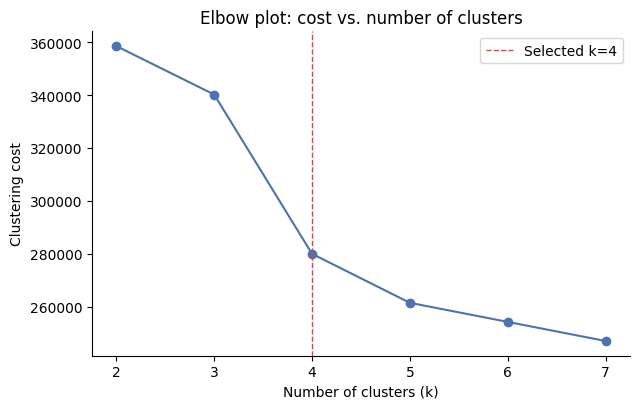

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(list(costs.keys()), list(costs.values()), marker='o', color='#4C72B0')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Clustering cost')
ax.set_title('Elbow plot: cost vs. number of clusters')
ax.axvline(4, color='#C44E52', linestyle='--', linewidth=1, label='Selected k=4')
ax.legend()
plt.tight_layout()
plt.show()

**Choosing k=4:** the cost drops sharply from k=3 to k=4, then flattens out — each additional cluster beyond 4 buys a much smaller reduction in cost. k=4 also keeps the result interpretable enough to describe each segment in plain business language, which matters more here than squeezing out the last bit of statistical fit.

## 4. Final Clustering (k=4)

In [6]:
kp_final = KPrototypes(n_clusters=4, init='Cao', n_init=1, random_state=42, verbose=0)
sample['cluster'] = kp_final.fit_predict(X_final, categorical=categorical_idx)

cluster_profile = sample.groupby('cluster')['is_fraud'].agg(['count', 'mean'])
cluster_profile.columns = ['Transactions', 'Fraud rate']
cluster_profile['Share of sample'] = cluster_profile['Transactions'] / len(sample)
overall_rate = sample['is_fraud'].mean()
cluster_profile

,Transactions,Fraud rate,Share of sample
cluster,,,
0,19724,0.05,0.49
1,1447,0.01,0.04
2,752,0.06,0.02
3,18077,0.02,0.45


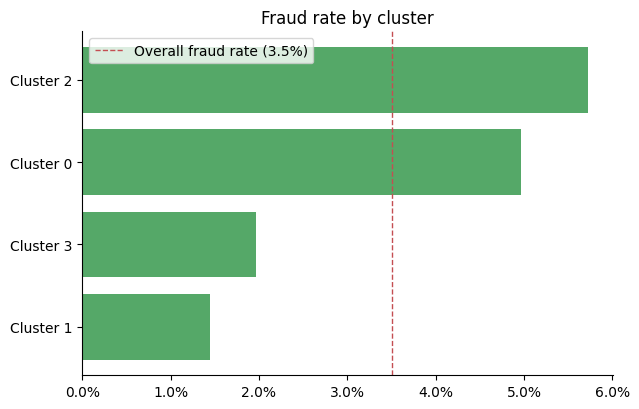

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
order = cluster_profile.sort_values('Fraud rate', ascending=True).index
ax.barh([f'Cluster {i}' for i in order], cluster_profile.loc[order, 'Fraud rate'], color='#55A868')
ax.axvline(overall_rate, color='#C44E52', linestyle='--', linewidth=1, label=f'Overall fraud rate ({overall_rate:.1%})')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Fraud rate by cluster')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Profiling the Clusters

To describe *what* distinguishes each cluster, we look at the numeric feature averages and the dominant category (with its share) for each categorical feature, cluster by cluster.

In [8]:
numeric_profile = sample.groupby('cluster')[numeric_cols].mean().round(1)
numeric_profile

,transaction_amount,c1,c2,c3,c4,c5,c6
cluster,,,,,,,
0,98.40,3.50,4.50,0.00,0.90,0.80,2.10
1,99.10,303.90,325.90,0.00,103.10,122.50,192.90
2,"1,397.70",1.80,1.60,0.00,0.10,0.80,1.30
3,125.40,3.20,3.00,0.00,0.00,1.50,2.40


In [9]:
def top_category(s):
    vc = s.value_counts(normalize=True)
    return f"{vc.index[0]} ({vc.iloc[0]:.0%})"

cat_profile = pd.DataFrame({
    c: sample.groupby('cluster')[c].astype(str).agg(top_category) if False else
       sample.assign(**{c: sample[c].astype('object').fillna('unknown').astype(str)}).groupby('cluster')[c].agg(top_category)
    for c in categorical_cols
})
cat_profile.T

cluster,0,1,2,3
product_code,W (49%),W (90%),W (96%),W (100%)
card_network,visa (64%),visa (68%),visa (61%),visa (66%)
card_type,debit (65%),debit (86%),credit (54%),debit (84%)
billing_country_code,87.0 (77%),87.0 (94%),87.0 (100%),87.0 (100%)
payer_email_domain,gmail.com (37%),gmail.com (36%),gmail.com (35%),gmail.com (40%)
device_type,unknown (52%),unknown (90%),unknown (96%),unknown (100%)
match_flag_1,unknown (90%),True (65%),True (71%),True (100%)
match_flag_2,unknown (90%),True (59%),True (61%),True (91%)
match_flag_3,unknown (90%),True (52%),True (52%),True (81%)
match_flag_4,unknown (53%),unknown (83%),unknown (64%),M0 (47%)


**Reading the profiles together:**

| Cluster | Size | Fraud rate | Profile |
|---|---|---|---|
| **2** | 752 (1.9%) | **5.7%** (highest) | Big-ticket transactions — average amount ~$1,400 vs. ~$100-125 elsewhere; majority **credit card** (54%) rather than debit, unlike every other cluster. |
| **0** | 19,724 (49.3%) | **5.0%** | Moderate transaction size (~$98); the one large cluster where device info is actually captured close to half the time (48% known device vs. 90-100% unknown elsewhere) and where match-flag data is mostly absent. |
| **3** | 18,077 (45.2%) | 2.0% (lowest of the two large clusters) | The largest, most "plain vanilla" segment — 100% product code W, 100% unknown device, but with match flags consistently *present* and matching (100% `match_flag_1 = True`). |
| **1** | 1,447 (3.6%) | 1.5% (lowest overall) | A distinct small segment with unusually **high anonymized `C` counts** (c1≈304, c2≈326, c4≈103 vs. single digits elsewhere) — likely cards or accounts associated with many linked addresses/devices, behaving more like frequently-reused or higher-activity payment instruments. |

**The pattern that matters most:** the two *higher-risk* segments (Cluster 2's big-ticket/credit transactions, Cluster 0's known-device transactions) both run at roughly 1.5-2x the baseline fraud rate, while the two *lower-risk* segments (Cluster 3's plain majority, Cluster 1's high-linkage cards) sit at roughly half the baseline. This echoes something we already saw in Phase 2's EDA — captured device information does not automatically mean lower risk; if anything, the reverse shows up here. That's worth carrying forward as a hypothesis to test formally in Phase 4's predictive model, rather than treating it as settled.

**An honest caveat:** none of these fraud rates are dramatically separated — we're looking at a range of roughly 1.5% to 5.7%, not, say, a "10x riskier" segment. These are behavioral clusters, not a fraud-detection rule on their own; they're useful for prioritizing *where* to look (e.g. extra scrutiny on large credit-card transactions), not for automatically flagging individual transactions.

## 6. Summary & Bridge to Phase 3

**What we learned:**
- Transactions naturally group into 4 behavioral segments even before we tell the model anything about fraud — driven mainly by transaction size, card type, device-capture status, and account-linkage signals (the `C` features).
- Fraud isn't evenly spread across these segments: **big-ticket, credit-card transactions** and **transactions with captured device data** run at roughly double the baseline fraud rate; the largest "plain vanilla" segment and the high-linkage-card segment run at about half.
- This gives a business-usable prioritization signal today (e.g. apply extra scrutiny to large credit-card transactions) even before any predictive model exists.

**Bridge to Phase 3:** these segment-level differences are suggestive, not definitive — a K-Prototypes clustering optimizes for overall similarity, not for fraud separation specifically. Phase 3's logistic regression (and comparison model) will test formally whether the individual features driving these clusters — transaction amount, card type, device-capture status, match flags — are statistically significant predictors of fraud on their own, and by how much, once we control for all of them simultaneously.
